<a href="https://colab.research.google.com/github/guebin/DL2026/blob/master/posts/02wk.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

# 1. 강의영상 

{{<video https://youtu.be/playlist?list=PLQqh36zP38-zzEbIB3mwwfZpDA9neTRkF&si=9zppjgOoIEAZS5GA>}}

# 2. Imports

In [1]:
import torch
import matplotlib.pyplot as plt

# 3. torch

## E. 차원, 전환

In [559]:
a = torch.tensor([[1,2,3,4],[2,2,0,1], [0,1,-1,0], [3,1,-1,3]])
a

tensor([[ 1,  2,  3,  4],
        [ 2,  2,  0,  1],
        [ 0,  1, -1,  0],
        [ 3,  1, -1,  3]])

`-` 미묘한차이

In [560]:
a[[0],:] # 1x4 matrix 형태, 2차원

tensor([[1, 2, 3, 4]])

In [561]:
a[0,:] # length-4 vector 형태, 1차원

tensor([1, 2, 3, 4])

In [562]:
a[:,[0]] # 4x1 matrix 형태, 2차원

tensor([[1],
        [2],
        [0],
        [3]])

In [563]:
a[:,0] # length-4 vector 형태, 1차원

tensor([1, 2, 0, 3])

In [564]:
a[0,0] # shape이 없는 형태, 0차원

tensor(1)

`-` 0차원, 1차원, 2차원....

In [565]:
torch.tensor([[1,2,3],[2,3,4]]), torch.tensor([[1,2,3],[2,3,4]]).shape # 2차원

(tensor([[1, 2, 3],
         [2, 3, 4]]),
 torch.Size([2, 3]))

In [566]:
torch.tensor([[1,2,3]]), torch.tensor([[1,2,3]]).shape # 2차원

(tensor([[1, 2, 3]]), torch.Size([1, 3]))

In [567]:
torch.tensor([[1],[2],[3]]), torch.tensor([[1],[2],[3]]).shape # 2차원

(tensor([[1],
         [2],
         [3]]),
 torch.Size([3, 1]))

In [568]:
torch.tensor([1,2,3]), torch.tensor([1,2,3]).shape # 1차원

(tensor([1, 2, 3]), torch.Size([3]))

In [569]:
torch.tensor([3]), torch.tensor([3]).shape # 1차원

(tensor([3]), torch.Size([1]))

In [570]:
torch.tensor(3), torch.tensor(3).shape # 0차원

(tensor(3), torch.Size([]))

In [571]:
torch.tensor([[3]]), torch.tensor([[3]]).shape # 2차원

(tensor([[3]]), torch.Size([1, 1]))

`-` reshape

In [572]:
a = torch.tensor([1,2,3,4,5,6])
a

tensor([1, 2, 3, 4, 5, 6])

In [573]:
a.reshape(1,6)

tensor([[1, 2, 3, 4, 5, 6]])

In [574]:
a.reshape(6,1)

tensor([[1],
        [2],
        [3],
        [4],
        [5],
        [6]])

In [575]:
a.reshape(3,2)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [576]:
a.reshape(2,3)

tensor([[1, 2, 3],
        [4, 5, 6]])

`# reshape 고급`

In [577]:
a = torch.tensor([[1,2,3],[4,5,6]])
a

tensor([[1, 2, 3],
        [4, 5, 6]])

*task1: [6,1]로 만들기*

In [578]:
a.reshape(6,1) # 방법1

tensor([[1],
        [2],
        [3],
        [4],
        [5],
        [6]])

In [579]:
a.reshape(6,-1) # 방법2

tensor([[1],
        [2],
        [3],
        [4],
        [5],
        [6]])

*task2: [3,2]로 만들기*

In [580]:
a.reshape(3,2) # 방법1

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [581]:
a.reshape(3,-1) # 방법2

tensor([[1, 2],
        [3, 4],
        [5, 6]])

*task3: [6]로 만들기*

In [582]:
a.reshape(6)

tensor([1, 2, 3, 4, 5, 6])

In [583]:
a.reshape(-1)

tensor([1, 2, 3, 4, 5, 6])

`#`

`-` 전치행렬 만들어보기

In [584]:
a = torch.tensor([[1,2,3],[2,3,4]])
a

tensor([[1, 2, 3],
        [2, 3, 4]])

In [585]:
a.T # 트랜스포즈하는 방법1

tensor([[1, 2],
        [2, 3],
        [3, 4]])

In [586]:
a.reshape(3,2) # 트랜스포즈실패: 내마음대로 안되네..

tensor([[1, 2],
        [3, 2],
        [3, 4]])

In [587]:
torch.einsum('ij -> ji',a) # 트랜스포즈하는 방법2

tensor([[1, 2],
        [2, 3],
        [3, 4]])

In [588]:
a.permute(1,0) # 트랜스포즈하는 방법3

tensor([[1, 2],
        [2, 3],
        [3, 4]])

`-` 벡터, col-vec, row-vec, matrix

*(1) 길이가 3인 벡터*

- ${\bf x}=[1,2,3]$

*(2) 차원이 (1,3)인 matrix = 길이가 3인 row-vec*

- ${\bf x}=\begin{bmatrix} 1 & 2 & 3 \end{bmatrix}$

*(3) 차원이 (3,1)인 matrix = 길이가 3인 col-vec*

- ${\bf x}=\begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix}=\begin{bmatrix} 1 & 2 & 3 \end{bmatrix}^\top$

*참고*

- 수학에서 벡터 ${\bf a},{\bf b}$는 보통 특별한 언급이 없으면 column-vector로 인식하는 경우가 많다. 이럴경우에 두 벡터의 내적은 ${\bf a}^\top {\bf b}$와 같이 표현된다.
- ref: <https://en.wikipedia.org/wiki/Dot_product>

`-` `.item()`

In [589]:
a = torch.tensor(32)
a

tensor(32)

In [590]:
a # 0차원텐서

tensor(32)

In [591]:
a.item() # int형변수

32

## F. `@`의 유연성

`-` 아래의 행렬곱은 연산가능함.

- (2,2) @ (2,1) -> (2,1)
- (1,2) @ (2,2) -> (1,2)


In [592]:
a = torch.tensor([1,2,3,4]).reshape(2,2)
b = torch.tensor([1,2]).reshape(2,1)
a@b

tensor([[ 5],
        [11]])

In [593]:
a = torch.tensor([1,2,3,4]).reshape(2,2)
b = torch.tensor([1,2]).reshape(1,2)
b@a

tensor([[ 7, 10]])

`-` 당연히 아래의 행렬곱은 연산불가능함.

- (2,1) @ (2,2) -> X
- (2,2) @ (1,2) -> X


In [594]:
a = torch.tensor([1,2,3,4]).reshape(2,2)
b = torch.tensor([1,2]).reshape(2,1)
b@a

RuntimeError: mat1 and mat2 shapes cannot be multiplied (2x1 and 2x2)

In [595]:
a = torch.tensor([1,2,3,4]).reshape(2,2)
b = torch.tensor([1,2]).reshape(1,2)
a@b

RuntimeError: mat1 and mat2 shapes cannot be multiplied (2x2 and 1x2)

`-` 그렇다면 아래는 어떨까?

- 2 @ (2,2) -> ??

In [596]:
a = torch.tensor([1,2,3,4]).reshape(2,2)
b = torch.tensor([1,2])

In [597]:
b @ a # 마치 b를 1x2 matrix로 해석하고 연산한뒤 그 결과를 1차원으로 다시 만든 느낌

tensor([ 7, 10])

In [598]:
(b.reshape(1,2) @ a).reshape(-1)

tensor([ 7, 10])

In [599]:
a @ b # 마치 b를 2x1 matrix로 해석하고 연산한뒤 그 결과를 1차원으로 다시 만든 느낌

tensor([ 5, 11])

`# 내적의 계산`: ${\bf a}=[1,2,3]$, ${\bf b}=[4,5,6]$ 일 경우 ${\bf a} \cdot {\bf b}$를 계산해보자.

계산방법1

In [600]:
a = torch.tensor([1,2,3])
b = torch.tensor([4,5,6])

In [601]:
(a*b).sum()

tensor(32)

계산방법2

In [602]:
a = torch.tensor([1,2,3]).reshape(3,1)
b = torch.tensor([4,5,6]).reshape(3,1)
a.T @ b

tensor([[32]])

계산방법3

In [603]:
a = torch.tensor([1,2,3])
b = torch.tensor([4,5,6])
a @ b

tensor(32)

- 좋은건가? 아니면 헷갈리는건가?
- 아는상태에서 쓰면 `@`의 유연성은 편리한 기능인데, 모르는 상태에서 쓰면 혼란스러울 수 있음.

`-` 결론: `@`의 유연성으로 인해서 불편할때도 있고, 편리할때도 있다.

## G. 다양한 array 생성

### `arange`

`-` 정수배열을 생성

In [604]:
torch.arange(10) # torch.arange(0,10)에서 0이 생략된 버전

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

`-` 위의코드는 사실 아래와 같음.

In [605]:
torch.arange(0,10) # 0부터 시작해서 10까지 정수배열을 만드는데, 끝점인 10은 제외

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

`-` 시작점을 다르게 할 수 있음.

In [606]:
torch.arange(1,10)

tensor([1, 2, 3, 4, 5, 6, 7, 8, 9])

`-` 간격을 다르게 할 수도 있음.

In [607]:
torch.arange(1,10,2)

tensor([1, 3, 5, 7, 9])

### `linspace`

`-` 등간격으로 숫자생성

In [608]:
torch.linspace(0,1,11)

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])

`-` 물론 `linspace`를 쓰지 않고 아래와 같이 만들어도 상관없긴함.

In [609]:
torch.arange(1,11)/10

tensor([0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000, 0.9000,
        1.0000])

### `zeros`, `ones`

`-` 모두 0이 채워진 배열생성

In [610]:
torch.zeros(5)

tensor([0., 0., 0., 0., 0.])

In [611]:
torch.arange(5)*0.0 # 물론이렇게 해도 괜찮음.

tensor([0., 0., 0., 0., 0.])

`-` 0만 채워진 2차원배열(행렬)을 생성할 수도 있음.

In [612]:
torch.zeros((5,5))

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

`-` 차원은 `(5,5)`로 전달하든 `[5,5]`로 전달하든 결과는 같음.

In [613]:
torch.zeros([5,5])

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

`-` `ones`도 마찬가지

In [614]:
torch.ones(5), torch.ones((5,5)), torch.ones([5,5])

(tensor([1., 1., 1., 1., 1.]),
 tensor([[1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.]]),
 tensor([[1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.]]))

### `rand`

`-` 0~1 사이에서 난수를 뽑아서 텐서를 채우는 방법

In [615]:
torch.rand(10)

tensor([0.8549, 0.5509, 0.2868, 0.2063, 0.4451, 0.3593, 0.7204, 0.0731, 0.9699,
        0.1078])

In [616]:
torch.rand((5,2))

tensor([[0.8829, 0.4132],
        [0.7572, 0.6948],
        [0.5209, 0.5932],
        [0.8797, 0.6286],
        [0.7653, 0.1132]])

`-` 약간의 응용

*1~2 사이에서 10개의 난수를 뽑아서 텐서를 채워보자.*



In [617]:
torch.rand(10) + 1

tensor([1.8559, 1.6721, 1.6267, 1.5691, 1.7437, 1.9592, 1.3887, 1.2214, 1.3742,
        1.1953])

*0~2 사이에서 10개의 난수를 뽑아서 텐서를 채워보자.*

In [618]:
torch.rand(10) * 2

tensor([1.4810, 0.5058, 0.4663, 1.8628, 1.9151, 1.1150, 0.8268, 0.8709, 1.4737,
        0.0662])

*1~3 사이에서 10개의 난수를 뽑아서 텐서를 채워보자.*

In [619]:
torch.rand(10) * 2 + 1

tensor([1.1828, 2.7988, 2.9872, 1.9406, 1.2098, 2.0273, 1.5348, 1.9981, 2.4895,
        2.4427])

### `randn`

> ref: https://docs.pytorch.org/docs/stable/generated/torch.randn.html

`-` $N(0,1)$에서 10개의 난수 생성

In [620]:
torch.randn(10)

tensor([-0.4225, -0.0832, -0.9837, -1.2494, -0.1883,  0.2827,  0.1305,  0.3303,
        -0.0773, -0.9224])

`-` $N(0,2^2)$에서 10개의 난수 생성

In [621]:
torch.randn(10)*2

tensor([-3.7882,  2.0113, -1.3897,  1.8125,  0.2145,  1.2250,  0.6593, -1.7526,
        -3.3536, -1.4494])

`-` $N(1,2^2)$에서 10개의 난수 생성

In [622]:
torch.randn(10)*2 + 1

tensor([ 2.9268,  1.2685,  2.0971,  5.2697, -0.7563, -3.1652,  4.6634, -0.1071,
         3.0790, -1.5202])

`# 예제` -- 다음 모형에서 관측값을 생성하라.

$$y_i = 2+ \epsilon_i, \quad \epsilon_i \overset{i.i.d.}{\sim} N(0,1), \quad i=1,2,\dots,50$$

(풀이)

In [623]:
eps = torch.randn(50)
y = 2 + eps
y

tensor([ 1.6162,  1.7325,  2.6794,  1.6053,  3.3272,  2.1106,  2.3374,  1.6799,
         0.7020,  1.2127,  3.7422,  2.5880,  2.2755,  1.0664,  1.8473,  1.4700,
         2.6340,  3.0036, -0.1881,  1.0073,  2.8885,  0.5133,  1.1102,  2.9005,
         2.1451,  3.3705,  1.6241,  2.1689,  1.4585,  1.8395,  2.9327,  2.0649,
         1.8059,  0.4860,  2.2961,  1.9063,  3.9939,  1.2799,  1.3948,  1.3761,
         1.5297,  1.1518,  0.4047,  2.5859,  0.9465,  0.9732,  2.3708,  1.0671,
         2.3073,  2.7593])

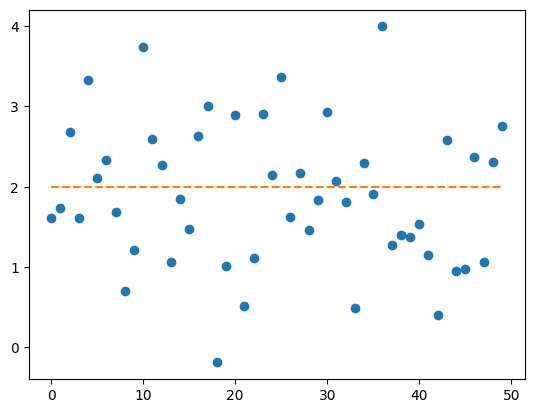

In [624]:
plt.plot(y,'o')
plt.plot(torch.ones(50)*2,'--')

`#`

`# 예제` -- ${\bf x} = [1,2,\cdots,10]$에 대하여, 다음 모형에서 관측값을 생성하라.

$$y_i = 2 + 1.5 x_i + \epsilon_i, \quad \epsilon_i \overset{i.i.d}{\sim} N(0,1),\quad i=1,2,\dots,10$$

In [625]:
x = torch.arange(1,11)
eps = torch.randn(10)
y = 2 + 1.5*x + eps
y

tensor([ 2.7808,  5.7129,  5.3665,  9.2743, 10.3017, 10.5058, 13.8967, 15.2540,
        15.2132, 18.4714])

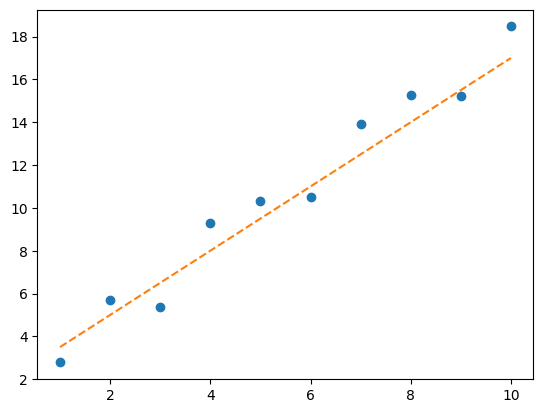

In [626]:
plt.plot(x,y,'o')
plt.plot(x,2+1.5*x,'--')

`#`

### `bernoulli`

> ref: <https://docs.pytorch.org/docs/stable/generated/torch.bernoulli.html>

`-` 사용시 주의점: 아래와 같이 1이 나올 확률에 해당하는 값을 꼭 tensor로 전달해야함.

In [627]:
torch.bernoulli(torch.tensor(0.5))

tensor(1.)

귀찮다고 아래와 같이 입력하면 에러가 발생한다.

In [628]:
torch.bernoulli(0.5)

TypeError: bernoulli(): argument 'input' (position 1) must be Tensor, not float

`# 예제` -- 다음 모형에서 관측값을 생성하라.

$$y_i \overset{i.i.d.}{\sim} \text{Bernoulli}(0.5), \quad i=1,2,\dots,100$$

In [629]:
p = torch.zeros(50) + 0.5
y = torch.bernoulli(p)
y

tensor([0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0.,
        1., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 1., 1.,
        1., 1., 0., 1., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0.])

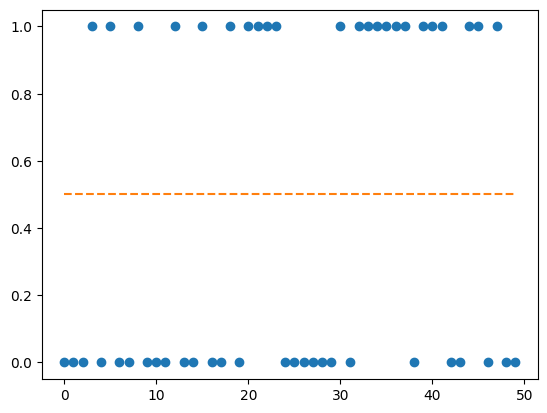

In [630]:
plt.plot(y, 'o')
plt.plot(p, '--')

*(별해): 이런식으로 할 수도 있어요*

In [631]:
y = (torch.rand(50) < 0.5).float()
y

tensor([0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 0., 1.,
        1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
        1., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1.])

`#`

`# 예제` -- 다음 모형에서 관측값을 생성하라.

$$y_i=\overset{i.i.d.}{\sim} \text{Bernoulli}(p_i),\quad p_i = \begin{cases} 0.1 & i=1,2,\dots,50 \\ 0.9 & i=51,52,\dots,100\end{cases}$$

(풀이)

In [632]:
p = torch.tensor([0.1] * 50 + [0.9] * 50)
y = torch.bernoulli(p)
y

tensor([1., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1., 0.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 0., 1.])

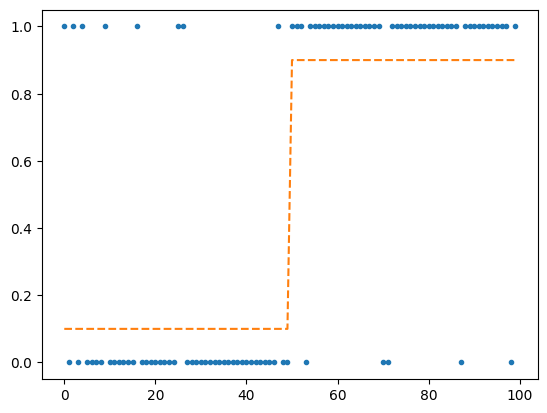

In [633]:
plt.plot(y,'.')
plt.plot(p,'--')

`# 예제` -- ${\bf x} = [-1.0, -0.9, \dots, 0.9, 1.0]$ 일떄, 다음 모형에서 관측값을 생성하라.

$$y_i \overset{i.i.d.}{\sim}\text{Bernoulli}(p_i), \quad p_i = \frac{\exp(6x_i + 0.5)}{\exp(6x_i+0.5)+1}$$

(풀이)

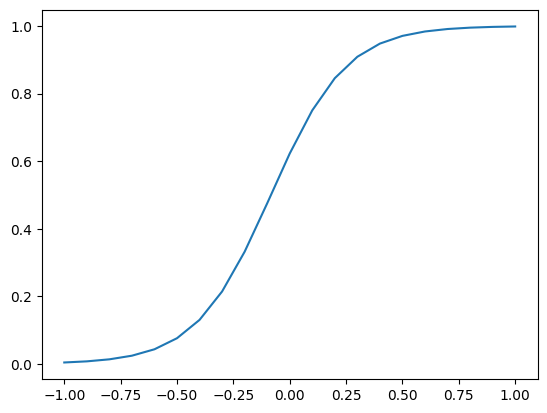

In [634]:
x = torch.arange(-10,11) / 10
p = torch.exp(6*x + 0.5) / (torch.exp(6*x+0.5) + 1)
plt.plot(x,p)

In [635]:
y = torch.bernoulli(p)
y

tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1.])

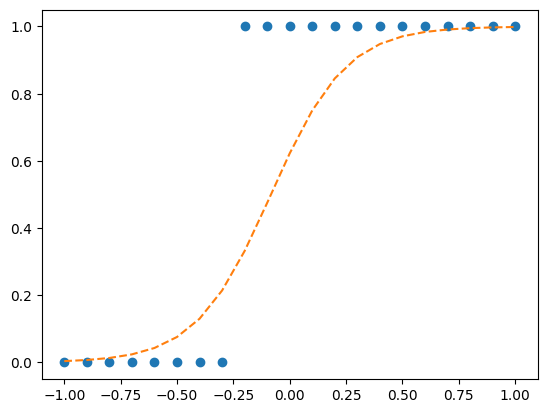

In [636]:
plt.plot(x,y,'o')
plt.plot(x,p,'--')

`#`

### `manual_seed`

`-` 아래를 여러번 실험해보자. --> 결과가 항상 바뀜

In [637]:
torch.rand(10)

tensor([0.1449, 0.9635, 0.0904, 0.1700, 0.5987, 0.6466, 0.9446, 0.5025, 0.8377,
        0.3333])

`-` 이번에는 아래를 여러번 실행해보자 --> 결과가 바뀌지 않음. (결과를 바꾸려면 seed를 바꿔야한다)

In [638]:
torch.manual_seed(7)
torch.rand(10)

tensor([0.5349, 0.1988, 0.6592, 0.6569, 0.2328, 0.4251, 0.2071, 0.6297, 0.3653,
        0.8513])

## H. `axis`

### `concat`

`-` 기본예제

In [639]:
a = torch.tensor([1,2])
b = -a

In [640]:
torch.concat([a,b])

tensor([ 1,  2, -1, -2])

`-` 응용

In [641]:
a = torch.tensor([1,2])
b = -a
c = torch.tensor([3,4,5])

In [642]:
torch.concat([a,b,c])

tensor([ 1,  2, -1, -2,  3,  4,  5])

- 지금까지는 딱히 concat의 메티르가 없어보임.
- a,b,c가 모두 리스트였다면 a+b+c하면 가능한 기능이니까.

`-` 2d array에 적용해보자.

In [643]:
a = torch.arange(4).reshape(2,2)
b = -a

In [644]:
torch.concat([a,b]) # torch.concat([a,b], axis=0) 의 생략버전

tensor([[ 0,  1],
        [ 2,  3],
        [ 0, -1],
        [-2, -3]])

`-` 옆으로 붙이고 싶다면??

In [645]:
torch.concat([a,b], axis=1)

tensor([[ 0,  1,  0, -1],
        [ 2,  3, -2, -3]])

`-` 위의 코드에서 `axis=1`이 의미하는게 뭘까? 그것을 알아보기 위해 `axis=0`, `axis=2`등을 입력해보자..

In [646]:
torch.concat([a,b], axis=0) # 아까 torch.concat([a,b])이거랑 결과가 같음.

tensor([[ 0,  1],
        [ 2,  3],
        [ 0, -1],
        [-2, -3]])

In [647]:
torch.concat([a,b], axis=2) # 이런건 없음..

IndexError: Dimension out of range (expected to be in range of [-2, 1], but got 2)

`-` axis의 의미가 뭔지 아직은 잘 모르겠음. 예제를 좀더 살펴보자.

In [648]:
a = torch.arange(24).reshape(2,3,4)
a # 3차원 array

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

In [649]:
b = -a
b

tensor([[[  0,  -1,  -2,  -3],
         [ -4,  -5,  -6,  -7],
         [ -8,  -9, -10, -11]],

        [[-12, -13, -14, -15],
         [-16, -17, -18, -19],
         [-20, -21, -22, -23]]])

In [650]:
torch.concat([a,b],axis=0)

tensor([[[  0,   1,   2,   3],
         [  4,   5,   6,   7],
         [  8,   9,  10,  11]],

        [[ 12,  13,  14,  15],
         [ 16,  17,  18,  19],
         [ 20,  21,  22,  23]],

        [[  0,  -1,  -2,  -3],
         [ -4,  -5,  -6,  -7],
         [ -8,  -9, -10, -11]],

        [[-12, -13, -14, -15],
         [-16, -17, -18, -19],
         [-20, -21, -22, -23]]])

In [651]:
torch.concat([a,b],axis=1)

tensor([[[  0,   1,   2,   3],
         [  4,   5,   6,   7],
         [  8,   9,  10,  11],
         [  0,  -1,  -2,  -3],
         [ -4,  -5,  -6,  -7],
         [ -8,  -9, -10, -11]],

        [[ 12,  13,  14,  15],
         [ 16,  17,  18,  19],
         [ 20,  21,  22,  23],
         [-12, -13, -14, -15],
         [-16, -17, -18, -19],
         [-20, -21, -22, -23]]])

In [652]:
torch.concat([a,b],axis=2)

tensor([[[  0,   1,   2,   3,   0,  -1,  -2,  -3],
         [  4,   5,   6,   7,  -4,  -5,  -6,  -7],
         [  8,   9,  10,  11,  -8,  -9, -10, -11]],

        [[ 12,  13,  14,  15, -12, -13, -14, -15],
         [ 16,  17,  18,  19, -16, -17, -18, -19],
         [ 20,  21,  22,  23, -20, -21, -22, -23]]])

- 이번에는 `axis=2`까지 동작함.

In [653]:
torch.concat([a,b],axis=3)

IndexError: Dimension out of range (expected to be in range of [-3, 2], but got 3)

`-` 뭔가 나름의 방식으로 합쳐지는데 원리가 뭘끼?

(분석1) -- `torch.concat([a,b],axis=0)`

In [654]:
a = torch.arange(24).reshape(2,3,4)
b = -a

In [655]:
a.shape, b.shape, torch.concat([a,b],axis=0).shape

(torch.Size([2, 3, 4]), torch.Size([2, 3, 4]), torch.Size([4, 3, 4]))

- 첫번째 차원이 바뀌었다 --> 첫번째 축(`axis`)이 바뀌었다. --> `axis=0`에 해당하는 축이 바뀌었다.

(분석2) -- `torch.concat([a,b],axis=1)`

In [656]:
a = torch.arange(24).reshape(2,3,4)
b = -a

In [657]:
a.shape, b.shape, torch.concat([a,b],axis=1).shape

(torch.Size([2, 3, 4]), torch.Size([2, 3, 4]), torch.Size([2, 6, 4]))

- 두번째 차원이 바뀌었다 --> 두번째 축(`axis`)이 바뀌었다. --> `axis=1`에 해당하는 축이 바뀌었다.

(분석3) -- `torch.concat([a,b],axis=2)`

In [658]:
a = torch.arange(24).reshape(2,3,4)
b = -a

In [659]:
a.shape, b.shape, torch.concat([a,b],axis=2).shape

(torch.Size([2, 3, 4]), torch.Size([2, 3, 4]), torch.Size([2, 3, 8]))

- 세번째 차원이 바뀌었다 --> 세번째 축(`axis`)이 바뀌었다. --> `axis=2`에 해당하는 축이 바뀌었다.

(분석4) -- `torch.concat([a,b],axis=3)`

In [660]:
a = torch.arange(24).reshape(2,3,4)
b = -a

In [661]:
a.shape, b.shape, torch.concat([a,b],axis=3).shape

IndexError: Dimension out of range (expected to be in range of [-3, 2], but got 3)

- 네번째 차원이 없음. --> 네번째 축(`axis`)이 없음. --> `axis=3`에 해당하는 축을 바꿀 수 없다.

`(보너스)` -- `torch.tensor([a,b],axis=-1)`

In [662]:
a = torch.arange(24).reshape(2,3,4)
b = -a

In [663]:
a.shape, b.shape, torch.concat([a,b],axis=-1).shape

(torch.Size([2, 3, 4]), torch.Size([2, 3, 4]), torch.Size([2, 3, 8]))

- 마지막 차원이 바뀌었음. --> 마지막 축(`axis`)이 바뀌었음. --> `axis=-1`에 해당하는 축이 바뀌었음.

아래도 마찬가지의 원리로 이해할 수 있다.

In [664]:
a.shape, b.shape, torch.concat([a,b],axis=-2).shape

(torch.Size([2, 3, 4]), torch.Size([2, 3, 4]), torch.Size([2, 6, 4]))

In [665]:
a.shape, b.shape, torch.concat([a,b],axis=-3).shape

(torch.Size([2, 3, 4]), torch.Size([2, 3, 4]), torch.Size([4, 3, 4]))

In [666]:
a.shape, b.shape, torch.concat([a,b],axis=-4).shape

IndexError: Dimension out of range (expected to be in range of [-3, 2], but got -4)

`-` 0차원은 축이 없으므로.. concat을 쓸수없다.

In [667]:
a = torch.tensor(1)
b = -a

In [668]:
torch.concat([a,b])

RuntimeError: zero-dimensional tensor (at position 0) cannot be concatenated

`-` 꼭 a,b가 같은 shape을 가지고 있을 필요는 없다.

In [669]:
a = torch.arange(4).reshape(2,2)
b = torch.arange(2).reshape(2,1)

In [670]:
torch.concat([a,b],axis=1)

tensor([[0, 1, 0],
        [2, 3, 1]])

In [671]:
torch.concat([b,a],axis=1)

tensor([[0, 0, 1],
        [1, 2, 3]])

### `stack`

`-` 혹시 아래가 가능할까??

- (3) concat (3) --> (3,2)

In [673]:
a = torch.tensor([1,2,3])
b = -a

In [676]:
torch.concat([a,b],axis=1)

IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

- 불가능

`-` 아래와 같이 하면 해결가능함. (하지만 귀찮다)

In [680]:
torch.concat([a.reshape(3,1), b.reshape(3,1)], axis=1)

tensor([[ 1, -1],
        [ 2, -2],
        [ 3, -3]])

`-` 위의 과정을 줄여서 아래와 같이 해도 같은 결과가 나온다.

In [684]:
torch.stack([a,b],axis=1)

tensor([[ 1, -1],
        [ 2, -2],
        [ 3, -3]])

`-` 아래와 같은 방식으로 붙이는것도 가능함.

In [685]:
torch.stack([a,b],axis=0)

tensor([[ 1,  2,  3],
        [-1, -2, -3]])

`-` 분석해보고 사용방법을 익히자.

(분석1)

In [686]:
a = torch.tensor([1,2,3])
b = -a

In [694]:
a.shape, b.shape, torch.stack([a,b],axis=0).shape

(torch.Size([3]), torch.Size([3]), torch.Size([2, 3]))

- (3) stack (3) --> (2,3) // 첫번째 위치에 추가된 축이 존재함 --> `axis=0`에 추가된 축이 존재함.

(분석2)

In [696]:
a = torch.tensor([1,2,3])
b = -a

In [697]:
a.shape, b.shape, torch.stack([a,b],axis=1).shape

(torch.Size([3]), torch.Size([3]), torch.Size([3, 2]))

- (3) stack (3) --> (2,3) // 두번째 위치에 추가된 축이 존재함 --> `axis=1`에 추가`된 축이 존재함.

`-` 고차원 예제

In [702]:
a = torch.arange(3*4*5).reshape(3,4,5)
b = -a

In [703]:
a.shape, b.shape

(torch.Size([3, 4, 5]), torch.Size([3, 4, 5]))

In [705]:
torch.stack([a,b],axis=0).shape # 2 3 4 5

torch.Size([2, 3, 4, 5])

In [706]:
torch.stack([a,b],axis=1).shape # 3 2 4 5

torch.Size([3, 2, 4, 5])

In [707]:
torch.stack([a,b],axis=2).shape # 3 4 2 5

torch.Size([3, 4, 2, 5])

In [708]:
torch.stack([a,b],axis=3).shape # 3 4 5 2

torch.Size([3, 4, 5, 2])

`-` 추가된 상태에서 원래 a,b에 해당하는것에 접근하고 싶다면

In [716]:
torch.stack([a,b],axis=0)[0,:,:,:],\
torch.stack([a,b],axis=0)[1,:,:,:]

(tensor([[[ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9],
          [10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19]],
 
         [[20, 21, 22, 23, 24],
          [25, 26, 27, 28, 29],
          [30, 31, 32, 33, 34],
          [35, 36, 37, 38, 39]],
 
         [[40, 41, 42, 43, 44],
          [45, 46, 47, 48, 49],
          [50, 51, 52, 53, 54],
          [55, 56, 57, 58, 59]]]),
 tensor([[[  0,  -1,  -2,  -3,  -4],
          [ -5,  -6,  -7,  -8,  -9],
          [-10, -11, -12, -13, -14],
          [-15, -16, -17, -18, -19]],
 
         [[-20, -21, -22, -23, -24],
          [-25, -26, -27, -28, -29],
          [-30, -31, -32, -33, -34],
          [-35, -36, -37, -38, -39]],
 
         [[-40, -41, -42, -43, -44],
          [-45, -46, -47, -48, -49],
          [-50, -51, -52, -53, -54],
          [-55, -56, -57, -58, -59]]]))

In [717]:
torch.stack([a,b],axis=1)[:,0,:,:],\
torch.stack([a,b],axis=1)[:,1,:,:]

(tensor([[[ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9],
          [10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19]],
 
         [[20, 21, 22, 23, 24],
          [25, 26, 27, 28, 29],
          [30, 31, 32, 33, 34],
          [35, 36, 37, 38, 39]],
 
         [[40, 41, 42, 43, 44],
          [45, 46, 47, 48, 49],
          [50, 51, 52, 53, 54],
          [55, 56, 57, 58, 59]]]),
 tensor([[[  0,  -1,  -2,  -3,  -4],
          [ -5,  -6,  -7,  -8,  -9],
          [-10, -11, -12, -13, -14],
          [-15, -16, -17, -18, -19]],
 
         [[-20, -21, -22, -23, -24],
          [-25, -26, -27, -28, -29],
          [-30, -31, -32, -33, -34],
          [-35, -36, -37, -38, -39]],
 
         [[-40, -41, -42, -43, -44],
          [-45, -46, -47, -48, -49],
          [-50, -51, -52, -53, -54],
          [-55, -56, -57, -58, -59]]]))

In [718]:
torch.stack([a,b],axis=2)[:,:,0,:],\
torch.stack([a,b],axis=2)[:,:,1,:]

(tensor([[[ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9],
          [10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19]],
 
         [[20, 21, 22, 23, 24],
          [25, 26, 27, 28, 29],
          [30, 31, 32, 33, 34],
          [35, 36, 37, 38, 39]],
 
         [[40, 41, 42, 43, 44],
          [45, 46, 47, 48, 49],
          [50, 51, 52, 53, 54],
          [55, 56, 57, 58, 59]]]),
 tensor([[[  0,  -1,  -2,  -3,  -4],
          [ -5,  -6,  -7,  -8,  -9],
          [-10, -11, -12, -13, -14],
          [-15, -16, -17, -18, -19]],
 
         [[-20, -21, -22, -23, -24],
          [-25, -26, -27, -28, -29],
          [-30, -31, -32, -33, -34],
          [-35, -36, -37, -38, -39]],
 
         [[-40, -41, -42, -43, -44],
          [-45, -46, -47, -48, -49],
          [-50, -51, -52, -53, -54],
          [-55, -56, -57, -58, -59]]]))

In [720]:
torch.stack([a,b],axis=3)[:,:,:,0],\
torch.stack([a,b],axis=3)[:,:,:,1]

(tensor([[[ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9],
          [10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19]],
 
         [[20, 21, 22, 23, 24],
          [25, 26, 27, 28, 29],
          [30, 31, 32, 33, 34],
          [35, 36, 37, 38, 39]],
 
         [[40, 41, 42, 43, 44],
          [45, 46, 47, 48, 49],
          [50, 51, 52, 53, 54],
          [55, 56, 57, 58, 59]]]),
 tensor([[[  0,  -1,  -2,  -3,  -4],
          [ -5,  -6,  -7,  -8,  -9],
          [-10, -11, -12, -13, -14],
          [-15, -16, -17, -18, -19]],
 
         [[-20, -21, -22, -23, -24],
          [-25, -26, -27, -28, -29],
          [-30, -31, -32, -33, -34],
          [-35, -36, -37, -38, -39]],
 
         [[-40, -41, -42, -43, -44],
          [-45, -46, -47, -48, -49],
          [-50, -51, -52, -53, -54],
          [-55, -56, -57, -58, -59]]]))

`-` `torch.concat`은 축의 총 갯수를 유지하면서 결합, `torch.stack`은 축의 갯수를 하나 늘리면서 결합

### `sum`

`-` 1차원

In [736]:
a = torch.tensor([1,2,3])
a

tensor([1, 2, 3])

In [739]:
a.sum() # a.sum(axis=0)의 생략버전이었음.

tensor(6)

In [740]:
a.sum(axis=0)

tensor(6)

`-` 2차원

In [742]:
a = torch.tensor([[1,2,3],[3,4,5]])
a

tensor([[1, 2, 3],
        [3, 4, 5]])

In [744]:
a.sum() # 모든 원소의 합

tensor(18)

In [748]:
a.sum(axis=0) # 열별로 합계를 구한결과

tensor([4, 6, 8])

In [749]:
a.sum(axis=1) # 행별로 합계를 구한결과

tensor([ 6, 12])

`-` 2차원 결과 분석

In [751]:
a.shape, a.sum(axis=0).shape

(torch.Size([2, 3]), torch.Size([3]))

- 첫번째 축이 삭제되었음 --> `axis=0`에 해당하는 축이 삭제되었음.

In [753]:
a.shape, a.sum(axis=1).shape

(torch.Size([2, 3]), torch.Size([2]))

- 두번째 축이 삭제되었음 --> `axis=1`에 해당하는 축이 삭제되었음.

In [756]:
a.sum().shape

torch.Size([])

- 첫번째랑 두번째 축이 삭제되었음 --> `axis=0`에 해당하는 축과 `axis=1`에 해당하는 축이 모두 삭제되었음.

In [758]:
a.sum(axis=(0,1))

tensor(18)

`# 예제` -- 아래의 텐서를 고려하자.

In [760]:
a = torch.arange(10).reshape(5,2)
a

tensor([[0, 1],
        [2, 3],
        [4, 5],
        [6, 7],
        [8, 9]])

`(1)` -- 1열의 합, 2열의 합을 계산하고 싶음..

(풀이)

> (5,2) --> (2) 이런식으로 되어야함. 그러면 `axis=0`이 삭제되어야하네?

In [762]:
a.sum(axis=0)

tensor([20, 25])

`(2)` -- 1행의 합, 2행의 합, ... ,5행의합을 계산하고 싶음.

(풀이)

> (5,2) --> (5) 이런식으로 되어야함. 그러면 `axis=-1` 이 삭제되어야하네?

In [766]:
a.sum(axis=-1)

tensor([ 1,  5,  9, 13, 17])

`#`

### `mean`

`-` sum이랑 유사한 논리

In [769]:
a = torch.tensor([[1,2,3],[3,4,5]]).float()
a

tensor([[1., 2., 3.],
        [3., 4., 5.]])

`axis=0`

In [770]:
a.mean(axis=0)

tensor([2., 3., 4.])

`axis=1`

In [771]:
a.mean(axis=1)

tensor([2., 4.])

`axis=(0,1)`

In [775]:
a.mean(axis=(0,1))

tensor(3.)

In [777]:
a.mean()

tensor(3.)

### `max`, `min`

In [810]:
torch.manual_seed(43052)
a = torch.randn(5,3)
a

tensor([[-0.8178, -0.7052, -0.5843],
        [-0.6179,  1.9949, -0.4724],
        [-0.9383,  1.6793, -1.4115],
        [ 0.8764, -0.5259, -1.2998],
        [-0.5652,  0.7329, -0.3414]])

In [812]:
a.max(), a.min()

(tensor(1.9949), tensor(-1.4115))

`axis=0`

In [817]:
a.max(axis=0)

torch.return_types.max(
values=tensor([ 0.8764,  1.9949, -0.3414]),
indices=tensor([3, 1, 4]))

In [819]:
a.min(axis=0)

torch.return_types.min(
values=tensor([-0.9383, -0.7052, -1.4115]),
indices=tensor([2, 0, 2]))

최대값, 최소값만을 깔끔하게 뽑고 싶다면??

In [830]:
a.max(axis=0)[0], a.min(axis=0)[0]

(tensor([ 0.8764,  1.9949, -0.3414]), tensor([-0.9383, -0.7052, -1.4115]))

`axis=1`

In [832]:
a

tensor([[-0.8178, -0.7052, -0.5843],
        [-0.6179,  1.9949, -0.4724],
        [-0.9383,  1.6793, -1.4115],
        [ 0.8764, -0.5259, -1.2998],
        [-0.5652,  0.7329, -0.3414]])

In [831]:
a.max(axis=1)

torch.return_types.max(
values=tensor([-0.5843,  1.9949,  1.6793,  0.8764,  0.7329]),
indices=tensor([2, 1, 1, 0, 1]))

In [833]:
a.min(axis=1)

torch.return_types.min(
values=tensor([-0.8178, -0.6179, -1.4115, -1.2998, -0.5652]),
indices=tensor([0, 0, 2, 2, 0]))

In [835]:
a.max(axis=1)[0], a.min(axis=1)[0]

(tensor([-0.5843,  1.9949,  1.6793,  0.8764,  0.7329]),
 tensor([-0.8178, -0.6179, -1.4115, -1.2998, -0.5652]))